In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import leagueleaders
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


/Users/ehabfaraj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Pull 2023-24 NBA season league leaders
leaders = leagueleaders.LeagueLeaders(season='2023-24', stat_category_abbreviation='PTS')
df = leaders.get_data_frames()[0]

print(df.shape)
df.head(10)

(572, 28)


,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612742,DAL,70,2624,804,1652,0.487,...,647,686,99,38,282,149,2370,2580,2.43,0.35
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,75,2553,796,1487,0.535,...,415,465,150,67,162,184,2254,2416,2.87,0.93
2,203507,3,Giannis Antetokounmpo,1610612749,MIL,73,2567,837,1369,0.611,...,841,476,87,79,250,210,2222,2655,1.90,0.35
3,1628973,4,Jalen Brunson,1610612752,NYK,77,2726,790,1648,0.479,...,278,519,70,13,186,144,2212,1972,2.79,0.38
4,203999,5,Nikola Jokić,1610612743,DEN,79,2737,822,1411,0.583,...,976,708,108,68,237,194,2085,3039,2.99,0.46
5,1630162,6,Anthony Edwards,1610612750,MIN,79,2770,718,1558,0.461,...,430,405,101,42,241,141,2049,1863,1.68,0.42
6,201142,7,Kevin Durant,1610612756,PHX,75,2791,751,1436,0.523,...,495,378,69,91,244,133,2032,2075,1.55,0.28
7,1628369,8,Jayson Tatum,1610612738,BOS,74,2645,672,1426,0.471,...,601,364,75,43,188,145,1987,2045,1.94,0.40
8,1628368,9,De'Aaron Fox,1610612758,SAC,74,2659,720,1549,0.465,...,340,418,150,31,194,193,1966,1771,2.16,0.77
9,201939,10,Stephen Curry,1610612744,GSW,74,2422,650,1445,0.450,...,330,379,54,28,210,117,1956,1717,1.81,0.26


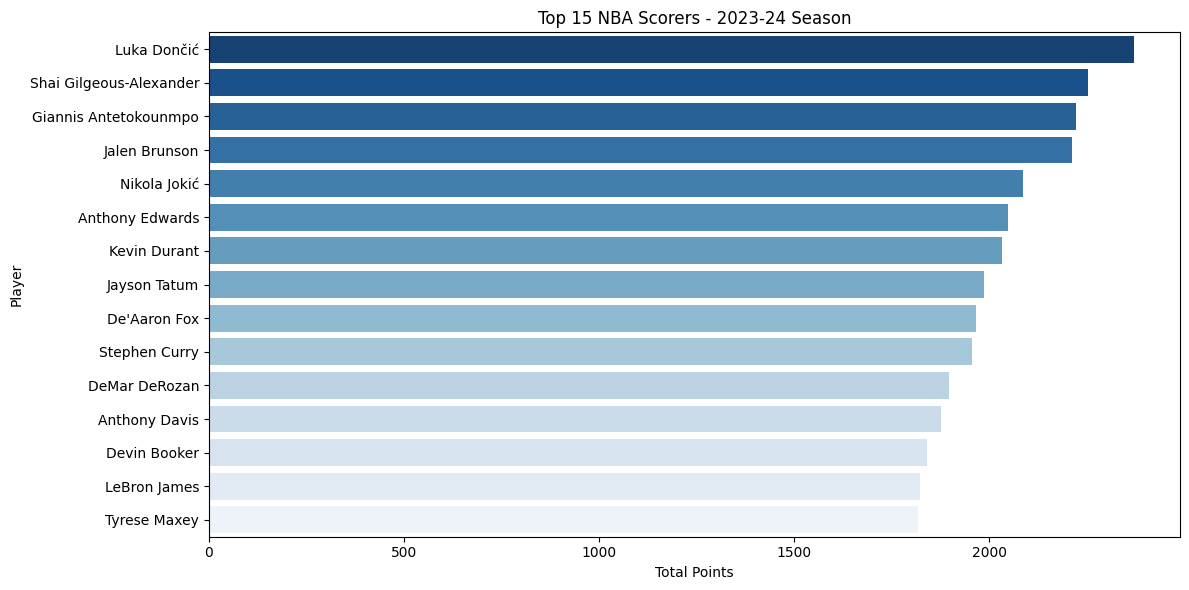

In [3]:
# Top 15 scorers in the 2023-24 season
top15 = df.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x='PTS', y='PLAYER', data=top15, hue='PLAYER', palette='Blues_r', legend=False)
plt.title('Top 15 NBA Scorers - 2023-24 Season')
plt.xlabel('Total Points')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

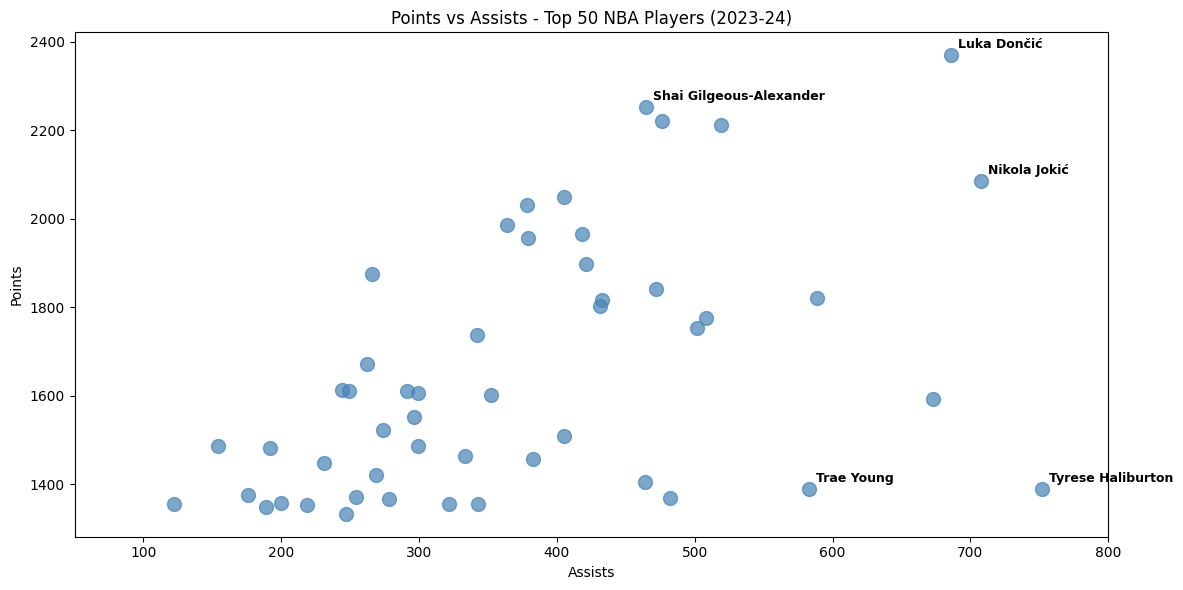

In [4]:
# Points vs Assists - who does both?
top50 = df.head(50)

plt.figure(figsize=(12,6))
plt.scatter(top50['AST'], top50['PTS'], alpha=0.7, color='steelblue', s=100)

# Only label the standouts
highlight = ['Luka Dončić', 'Shai Gilgeous-Alexander', 'Nikola Jokić', 'Tyrese Haliburton', 'Trae Young']
for i, row in top50.iterrows():
    if row['PLAYER'] in highlight:
        plt.annotate(row['PLAYER'], (row['AST'], row['PTS']), fontsize=9, fontweight='bold', 
                    xytext=(5,5), textcoords='offset points')

plt.title('Points vs Assists - Top 50 NBA Players (2023-24)')
plt.xlabel('Assists')
plt.ylabel('Points')
plt.xlim(50, 800)
plt.tight_layout()
plt.show()

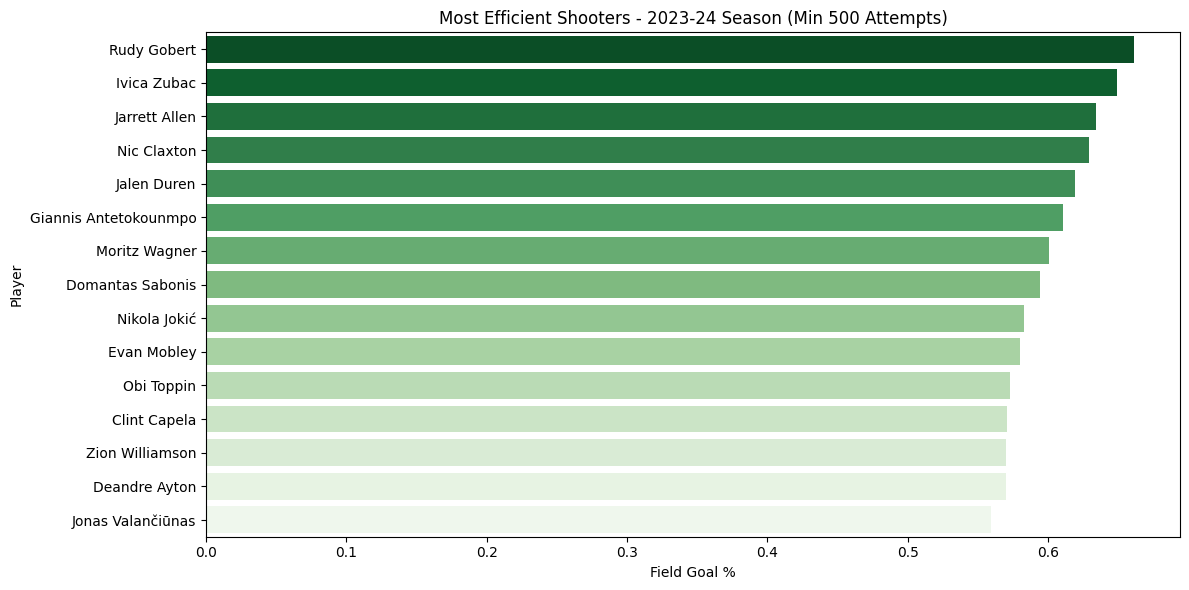

In [5]:
# Top 15 players by field goal percentage (min 500 attempts)
efficient = df[df['FGA'] >= 500].nlargest(15, 'FG_PCT')

plt.figure(figsize=(12,6))
sns.barplot(x='FG_PCT', y='PLAYER', data=efficient, hue='PLAYER', palette='Greens_r', legend=False)
plt.title('Most Efficient Shooters - 2023-24 Season (Min 500 Attempts)')
plt.xlabel('Field Goal %')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

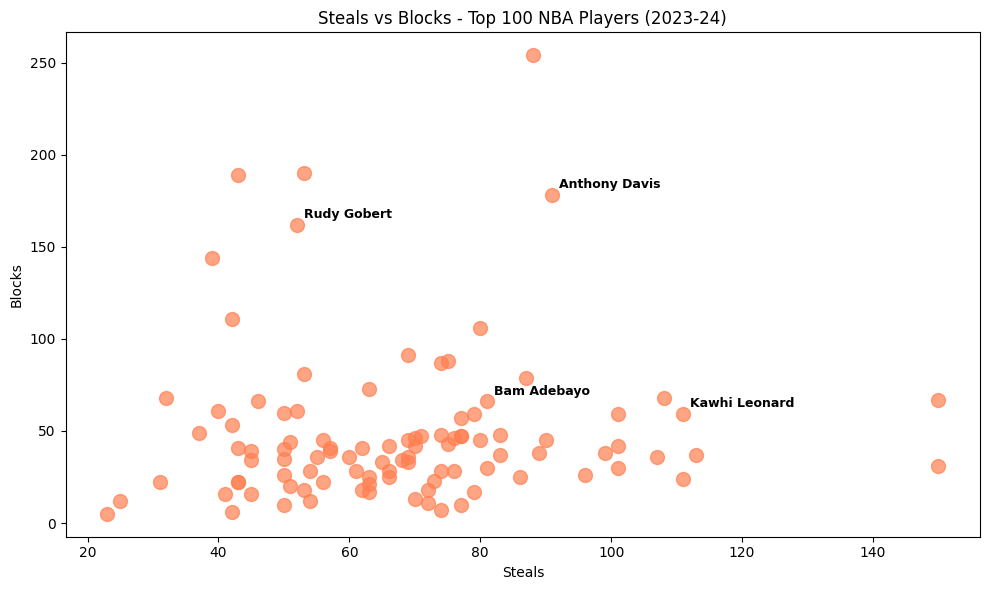

In [6]:
# Steals vs Blocks - best defenders
top100 = df.head(100)

plt.figure(figsize=(10,6))
plt.scatter(top100['STL'], top100['BLK'], alpha=0.7, color='coral', s=100)

# Label standout defenders
highlight = ['Rudy Gobert', 'Bam Adebayo', 'Anthony Davis', 'Kawhi Leonard', 'OG Anunoby']
for i, row in top100.iterrows():
    if row['PLAYER'] in highlight:
        plt.annotate(row['PLAYER'], (row['STL'], row['BLK']), fontsize=9, fontweight='bold',
                    xytext=(5,5), textcoords='offset points')

plt.title('Steals vs Blocks - Top 100 NBA Players (2023-24)')
plt.xlabel('Steals')
plt.ylabel('Blocks')
plt.tight_layout()
plt.show()

In [7]:
print("=== NBA 2023-24 Season Key Findings ===")
print(f"Total players analyzed: {len(df):,}")
print(f"Top scorer: {df.iloc[0]['PLAYER']} ({df.iloc[0]['PTS']:,} points)")
print(f"Most assists: {df.nlargest(1, 'AST').iloc[0]['PLAYER']} ({df.nlargest(1, 'AST').iloc[0]['AST']:,} assists)")
print(f"Most efficient shooter: {df[df['FGA'] >= 500].nlargest(1, 'FG_PCT').iloc[0]['PLAYER']}")
print(f"Most blocks: {df.nlargest(1, 'BLK').iloc[0]['PLAYER']} ({df.nlargest(1, 'BLK').iloc[0]['BLK']:,} blocks)")
print(f"Most steals: {df.nlargest(1, 'STL').iloc[0]['PLAYER']} ({df.nlargest(1, 'STL').iloc[0]['STL']:,} steals)")

=== NBA 2023-24 Season Key Findings ===
Total players analyzed: 572
Top scorer: Luka Dončić (2,370 points)
Most assists: Tyrese Haliburton (752 assists)
Most efficient shooter: Rudy Gobert
Most blocks: Victor Wembanyama (254 blocks)
Most steals: Shai Gilgeous-Alexander (150 steals)
